**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update your Course 1 notebook with links to your own work once completed!

# Activity 3.2.4 Applying non-parametric tests to a data set

## Scenario
As a data scientist working for an online retail brand, you have been tasked with comparing the customer engagement levels of two new marketing campaigns: Campaign A and Campaign B. To accomplish this, the brand has provided a data set containing engagement scores for each campaign. Your goal is to determine which campaign was more effective in engaging customers.


## Objective
The goal is to compare the effectiveness of two distinct marketing campaigns. The key metric for comparison is the 'Engagement Score', which reflects customer engagement levels with each campaign.

## Assignment criterion
By completing this activity, you will be able to provide evidence that you can demonstrate how to accurately apply parametric and non-parametric methods to analyse diverse data sets.

## Activity guidance
1. Import the necessary libraries and load the data set.
2. Perform an exploratory data analysis to get insights into the data's distribution and potential outliers.
3. Check the distribution of the data using a Shapiro-Wilk test.
4. Formulate a hypothesis to test.
5. Select an appropriate non-parametric test and apply it to the data set to determine if there's a significant difference in engagement between the campaigns.
6. Summarise and interpret your findings. What do the results reveal about the data set and your hypothesis?
6. Reflect critically about the implications of your findings.


> Start your activity here. Select the pen from the toolbar to add your entry.

In [2]:
# Import the necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import mannwhitneyu, shapiro, kstest, norm

# Load the dataset.
data = pd.read_csv('https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/marketing_campaign_data.csv')

data.head(200)

,Campaign,Engagement Score
0,A,59.393215
1,A,74.367043
2,A,64.248704
3,A,59.039486
4,A,48.128932
...,...,...
195,B,51.784411
196,B,32.056097
197,B,34.076736
198,B,19.352187


In [ ]:
data.shape

(200, 2)

# EDA

### Boxplots

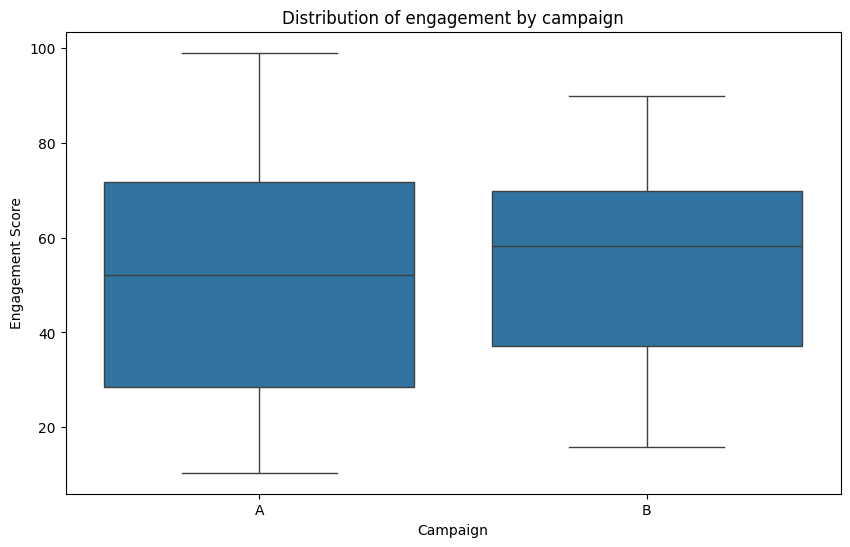

In [4]:
# Use a box plot to show engagement for each campaign.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Campaign', y='Engagement Score', data=data)
plt.title('Distribution of engagement by campaign')
plt.show()

### Histogram

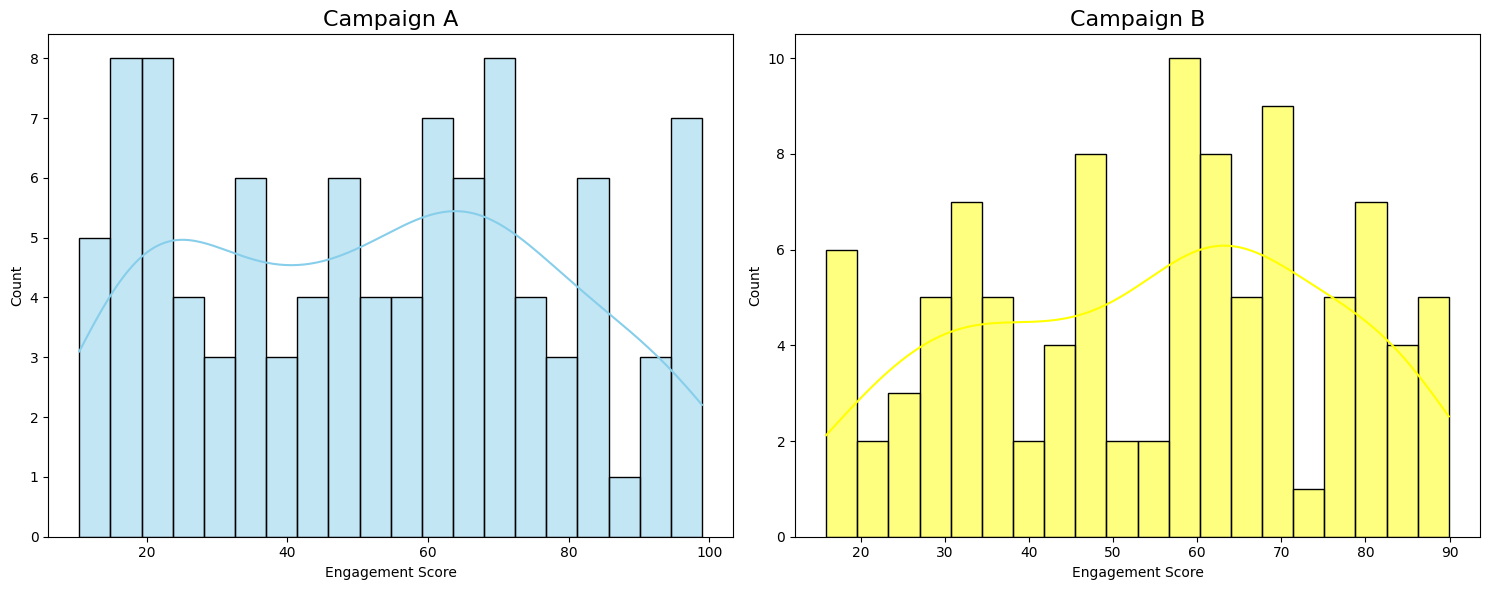

In [ ]:
# create a Face Grid for single row layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['skyblue', 'yellow']

# Plot histogram for Campaign
for ax, color, campaign in zip(axes, colors, ['A', 'B']):
    campaign_data = data[data['Campaign'] == campaign]['Engagement Score']

    #create a temporary data frame
    dataframe = pd.DataFrame({'Engagement Score' : campaign_data})

    # Plot histogram
    sns.histplot(data=dataframe,
                 x='Engagement Score',
                 bins=20,
                 ax=ax,
                 color=color,
                 kde=True)

    ax.set_title(f'Campaign {campaign}', fontsize=16)

# View the plot.
plt.tight_layout()
plt.show()

In [ ]:
# Drop Engagement
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign          200 non-null    object 
 1   Engagement Score  200 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.3+ KB


# Q-Q Plot

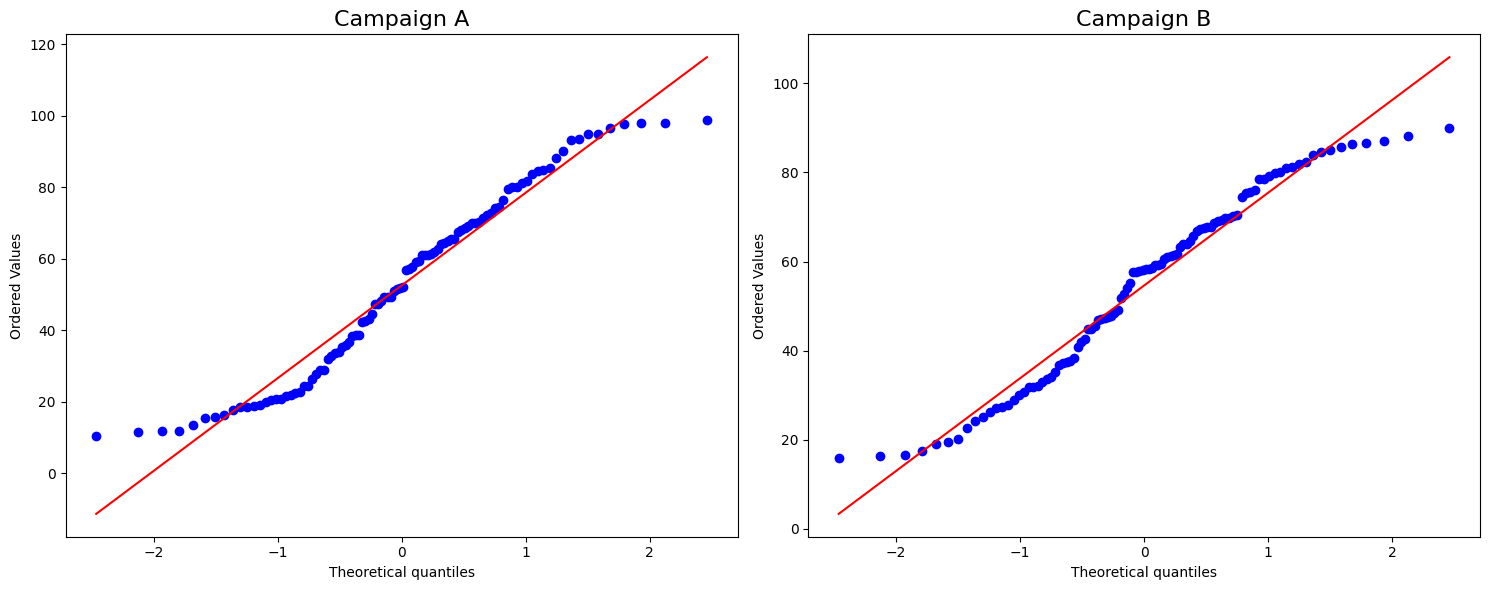

In [ ]:
# create a Face Grid for single row layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['skyblue', 'salmon']

# Plot histogram for Campaign A and B
for ax, color, campaign in zip(axes, colors, ['A', 'B']):
    campaign_data = data[data['Campaign'] == campaign]['Engagement Score']

    stats.probplot(campaign_data, dist="norm", plot=ax)
    ax.set_title(f'Campaign {campaign}', fontsize=16)

# View the plot.
plt.tight_layout()
plt.show()

# Kolmogrov Test - Normality Test

In [ ]:
# Perfomr the Kolmogrov-Smirnov test for normality for Campaign A
stat, p = kstest(data[data['Campaign'] == 'A']['Engagement Score'], cdf='norm')
print('C A statistic:', stat)
print('C A p-value:', p)

# Perform the Kolmogrov-Smirnov test for normality for Campaign B
stat, p = kstest(data[data['Campaign'] == 'B']['Engagement Score'], cdf='norm')
print('\nC B statistic:', stats)
print('C B p-value:', p)



C A statistic: 1.0
C A p-value: 0.0

C B statistic: 1.0
C B p-value: 0.0


# Shapiro Test

In [ ]:
# Perform the Shapiro-Wilk test for normality for Campaign A
stat, p = shapiro(data[data['Campaign'] == 'A']['Engagement Score'])
print('C A statistic:', stat)
print('C A p-value:', p)


# Perform the Shapiro-Wilk test for normality for Campaign A
stat, p = shapiro(data[data['Campaign'] == 'B']['Engagement Score'])
print('\nC A statistic:', stat)
print('C A p-value:', p, "\n")


# Interpret.
alpha = 0.05
if p > alpha:
    print('Sample looks normally distributed  (fail to reject H0)')
else:
    print('Sample does not look normally distributed (reject H0)')


C A statistic: 0.9510603435816445
C A p-value: 0.0009749754084064827

C A statistic: 0.958954389888712
C A p-value: 0.0033892946595134553 

Sample does not look normally distributed (reject H0)


# Mann-Whitney U-test ( Independent Groups )

In [ ]:
# Perform a Mann-Whitney U test

stat, p = mannwhitneyu(data[data['Campaign'] == 'A']['Engagement Score'],
                       data[data['Campaign'] == 'B']['Engagement Score'])
print('Mann-Whitney U statistic:', stat)
print('Mann-Whitney U p-value:', p, "\n")

alpha = 0.05
if p > alpha:
    print('Sample looks normally distributed  (fail to reject H0)')
else:
    print('Sample does not look normally distributed (reject H0)')


Mann-Whitney U statistic: 4741.0
Mann-Whitney U p-value: 0.5276378110739883 

Sample looks normally distributed  (fail to reject H0)


The hypotheses statistic ($U$) has a value of 4741.0. The $p$ value .5276 which is greater than alpha($\alpha)=0.05$. Hence we can conclude that it is not possible to reject the value of $H_0$.

# Reflect

Write a brief paragraph highlighting your process and the rationale to showcase critical thinking and problem-solving.

> Select the pen from the toolbar to add your entry. When you have completed the activity, remember to update the link on your contents page to point to your completed Notebook.